# Cancer Prediction 🩺📊
<div align="center">
    <img src="cancer.jpg" width="950">
</div>

### Table of Contents
- [1. Introduction](#1-introduction)

- [2. Dataset Overview](#2-dataset-overview)

- [3. Exploratory Data Analysis](#3-exploratory-data-analysis)

- [4. Statistical Analysis](#4-statistical-analysis)

- [5. Logistic Regression Model](#5-logistic-regression-model)

- [6. Model Evaluation](#6-model-evaluation)

- [7. Feature Importance Analysis](#7-feature-importance-analysis)

- [8. Final Conclusion](#8-final-conclusion)

- [9. Limitations](#9-limitations)

- [10. Ethical Considerations](#10-ethical-consideration)

### 1. Introduction
### Project Objective
Cancer is a serious issue facing society today. Just in the US, the National Cancer Institute reported that, “an estimated 2,041,910 new cases of cancer will be diagnosed in the United States and 618,120 people will die from the disease.” ([National Cancer Institute](<https://pmc.ncbi.nlm.nih.gov/articles/PMC2515569/)>)) While these figures highlight a major public health crisis, a big portion of these cases do not come from genetic defects. According to the National Library of Medicine, “Only 5–10% of all cancer cases can be attributed to genetic defects, whereas the remaining 90–95% have their roots in the environment and lifestyle.” ([PMC](https://pmc.ncbi.nlm.nih.gov/articles/PMC2515569/)) Together, these statistics emphasize the need for widespread initiatives to understand what the traits of a healthy lifestyle are.

### Group Member
- Adit Gautam
- Hsin Yu Ho
- Skyler Kim 
- Somprat Suratannon
- Noah Teng

### Research Question
Among individuals without a cancer diagnosis, what demographic, lifestyle, and risk factors are most common compared to those who are diagnosed?

### Hypothesis

Individuals without a cancer diagnosis past retirement age (65) are more likely to exhibit lower exposure to risk factors, such as smoking, alcohol consumption, and poor physical health compared to individuals who are diagnosed with cancer.

### Data
Our ideal data should include at least 1000 observations from a diverse demographic pool of patients that account for a wide range of ages, lifestyle habits, and physical fitness which would allow us to indicate the frequency of good and bad habits in the patient’s life. These variables would provide crucial information in showing whether these choices might lead to cancer or away from it. 

For these reasons we decided to use Rabie El Kharoua’s [Cancer Prediction Dataset](https://www.kaggle.com/datasets/rabieelkharoua/cancer-prediction-dataset) which was  synthetically generated with 1500 observations ranging from 20 to 80 years olds which included many lifestyle factors and basic health information. The dataset has 943 healthy patients and 557 cancer patients has 9 columns: 

- Age: Integer values representing the patient's age, ranging from 20 to 80.  
- Gender: Binary values representing gender, where 0 indicates Male and 1 indicates Female.
- BMI: Continuous values representing Body Mass Index, ranging from 15 to 40.  
- Smoking: Binary values indicating smoking status, where 0 means No and 1 means Yes.
- GeneticRisk: Categorical values representing genetic risk levels for cancer ranging from 0 to 2, with 0 indicating Low, 1 indicating Medium, and 2 indicating High.  
- Physical Activity: Continuous values representing the number of hours per week spent on physical activities, ranging from 0 to 10.  
- AlcoholIntake: Continuous values representing the number of alcohol units consumed per week, ranging from 0 to 5.  
- CancerHistory: Binary values indicating whether the patient has a personal history of cancer, where 0 means No and 1 means Yes.  
- Diagnosis: Binary values indicating the cancer diagnosis status, where 0 indicates No Cancer and 1 indicates Cancer.

Dataset Name: 🩺📊 Cancer Prediction Dataset 🌟🔬

Link to the dataset: https://www.kaggle.com/datasets/rabieelkharoua/cancer-prediction-dataset 

### 2. Dataset Overview

In [69]:
import pandas as pd
import numpy as np
import statistics
import seaborn as sns
import plotly.express as px
import matplotlib as mpl
import matplotlib.pyplot as plt 
import matplotlib.style as style
import statsmodels.api as sm
import scipy.stats as stats
from scipy.stats import ttest_ind, normaltest
from statsmodels.formula.api import ols
from statsmodels.stats.anova import anova_lm
from sklearn.model_selection import train_test_split, cross_val_score, GridSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    ConfusionMatrixDisplay,
    roc_auc_score,
    roc_curve,
    classification_report
)

In [3]:
cancer = pd.read_csv('The_Cancer_data_1500_V2.csv')
cancer

,Age,Gender,BMI,Smoking,GeneticRisk,PhysicalActivity,AlcoholIntake,CancerHistory,Diagnosis
0,58,1,16.085313,0,1,8.146251,4.148219,1,1
1,71,0,30.828784,0,1,9.361630,3.519683,0,0
2,48,1,38.785084,0,2,5.135179,4.728368,0,1
3,34,0,30.040296,0,0,9.502792,2.044636,0,0
4,62,1,35.479721,0,0,5.356890,3.309849,0,1
...,...,...,...,...,...,...,...,...,...
1495,62,1,25.090025,0,0,9.892167,1.284158,0,1
1496,31,0,33.447125,0,1,1.668297,2.280636,1,1
1497,63,1,32.613861,1,1,0.466848,0.150101,0,1
1498,55,0,25.568216,0,0,7.795317,1.986138,1,1


Columns:
- Age: Integer values; range: 20 to 80.  
- Gender: Binary values; 0: Male, 1: Female.
- BMI: Continuous values; range: 15 to 40.  
- Smoking: Binary values; 0: No, 1: Yes.
- GeneticRisk: Categorical values; 0: Low, 1: Medium, 2: High.  
- Physical Activity: Continuous values; range: 0 to 10.  
- AlcoholIntake: Continuous values; range: 0 to 5.  
- CancerHistory: Binary values; 0: No, 1: Yes.  
- Diagnosis: Binary values; 0: No Cancer, 1: Cancer.


In [4]:
continous_cols = ['Age', 'PhysicalActivity', 'AlcoholIntake', 'BMI']
categorical_cols = ["Smoking", "Gender", "GeneticRisk", "CancerHistory"]

Check NaN/ missing values.

In [5]:
print(cancer.isnull().any())
print('Number of NaN values in the dataset: ' + str(cancer.isnull().sum().sum()))

Age                 False
Gender              False
BMI                 False
Smoking             False
GeneticRisk         False
PhysicalActivity    False
AlcoholIntake       False
CancerHistory       False
Diagnosis           False
dtype: bool
Number of NaN values in the dataset: 0


The dataset is tidy.

Then, use the Interquartile Range (IQR) method to identify if any outliers in the dataset.

Outliers in 'Age': []
Outliers in 'PhysicalActivity': []
Outliers in 'AlcoholIntake': []
Outliers in 'BMI': []


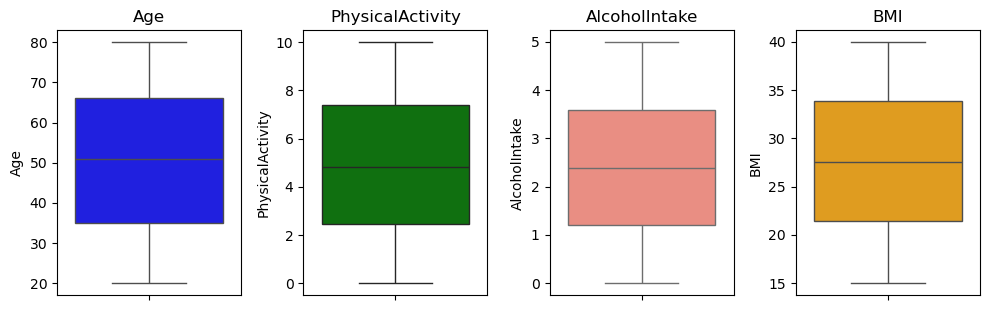

In [6]:
outliers = {}
for col in continous_cols:
    Q1 = cancer[col].quantile(0.25)
    Q3 = cancer[col].quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    outlier_idx = cancer[(cancer[col] < lower_bound) | (cancer[col] > upper_bound)].index
    outliers[col] = outlier_idx.append(outlier_idx).tolist()
    print(f"Outliers in '{col}':", outliers[col])
    
plt.figure(figsize=(10, 6))
colors = ['blue', 'green', 'salmon', 'orange']
for i, col in enumerate(continous_cols):
    plt.subplot(2, 4, i+1)
    sns.boxplot(y=cancer[col], color=colors[i % len(colors)])
    plt.title(col)
plt.tight_layout()
plt.show()

No outliers.

In [7]:
cancer.describe()

,Age,Gender,BMI,Smoking,GeneticRisk,PhysicalActivity,AlcoholIntake,CancerHistory,Diagnosis
count,1500.000000,1500.000000,1500.000000,1500.000000,1500.000000,1500.000000,1500.000000,1500.000000,1500.000000
mean,50.320000,0.490667,27.513321,0.269333,0.508667,4.897929,2.417987,0.144000,0.371333
std,17.640968,0.500080,7.230012,0.443761,0.678895,2.866162,1.419318,0.351207,0.483322
min,20.000000,0.000000,15.000291,0.000000,0.000000,0.002410,0.001215,0.000000,0.000000
25%,35.000000,0.000000,21.483134,0.000000,0.000000,2.434609,1.210598,0.000000,0.000000
50%,51.000000,0.000000,27.598494,0.000000,0.000000,4.834316,2.382971,0.000000,0.000000
75%,66.000000,1.000000,33.850837,1.000000,1.000000,7.409896,3.585624,0.000000,1.000000
max,80.000000,1.000000,39.958688,1.000000,2.000000,9.994607,4.987115,1.000000,1.000000


In [8]:
df = cancer.copy()
df['Gender'] = df['Gender'].map({0: 'Male', 1: 'Female'})   
df.groupby('Gender').count()['Smoking']

Gender
Female    736
Male      764
Name: Smoking, dtype: int64

### 3. Exploratory Data Analysis
#### Correlation Heatmap
Visualizing a correlation heatmap of age, PhysicalActivity, BMI, and AlcoholIntake.

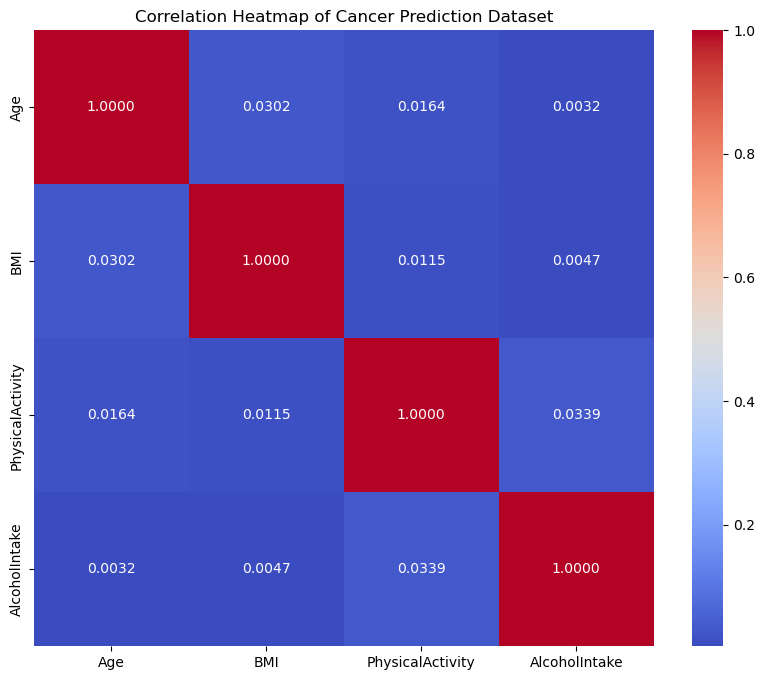

In [9]:
plt.figure(figsize=(10, 8))
for_heatmap = cancer[['Age', 'BMI', 'PhysicalActivity', 'AlcoholIntake']]
corr = sns.heatmap(for_heatmap.corr(), annot=True, cmap='coolwarm', fmt=".4f")
plt.title('Correlation Heatmap of Cancer Prediction Dataset')
plt.show()

#### Density Plots
To see relationship between continuous and categorical variables, we use density plots to see the relationship.

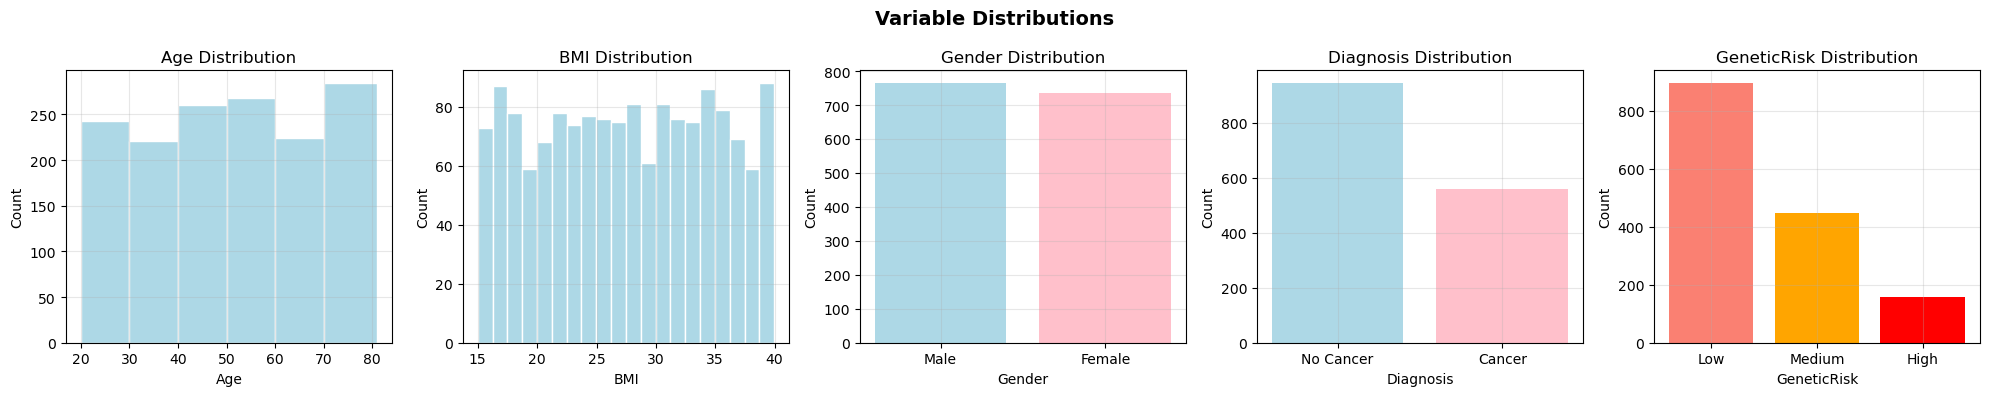

In [122]:
fig, axes = plt.subplots(1, 5, figsize=(20, 4))

axes[0].hist(cancer['Age'], bins=[20, 30, 40, 50, 60, 70, 81], color='lightblue', edgecolor='white')

axes[1].hist(cancer['BMI'], bins=20, color='lightblue', edgecolor='white')

gender_counts = cancer['Gender'].value_counts().sort_index()
axes[2].bar(['Male', 'Female'], gender_counts, color=['lightblue', 'pink'])

diagnosis_counts = cancer['Diagnosis'].value_counts().sort_index()
axes[3].bar(['No Cancer', 'Cancer'], diagnosis_counts, color=['lightblue', 'pink'])

genetic_counts = cancer['GeneticRisk'].value_counts().sort_index()
axes[4].bar(['Low', 'Medium', 'High'], genetic_counts, color=['salmon', 'orange', 'red'])

def format_plot(ax, title, xlabel, ylabel):
    ax.set_title(title)
    ax.set_xlabel(xlabel)
    ax.set_ylabel(ylabel)
    ax.grid(True, alpha=0.3)
    
format_plot(axes[0], 'Age Distribution', 'Age', 'Count')
format_plot(axes[1], 'BMI Distribution', 'BMI', 'Count')
format_plot(axes[2], 'Gender Distribution', 'Gender', 'Count')
format_plot(axes[3], 'Diagnosis Distribution', 'Diagnosis', 'Count')
format_plot(axes[4], 'GeneticRisk Distribution', 'GeneticRisk', 'Count')

plt.suptitle('Variable Distributions', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

We can see that the age in range [70, 80] is more than age in range [30, 40).

In [20]:
count_max = cancer[(cancer['Age'] >= 50) & (cancer['Age'] <= 80)]['Age'].count()
count_min = cancer[(cancer['Age'] >= 20) & (cancer['Age'] < 50)]['Age'].count()
age_diff = count_max - count_min
age_diff

np.int64(52)

Since there are 52 more patients in the age range [50, 81) than in [20, 50), the dataset is skewed toward older patients. This imbalance may bias statistical analysis and predictive models toward patterns associated with older individuals.

#### Bar Plots 
Categorical Variables

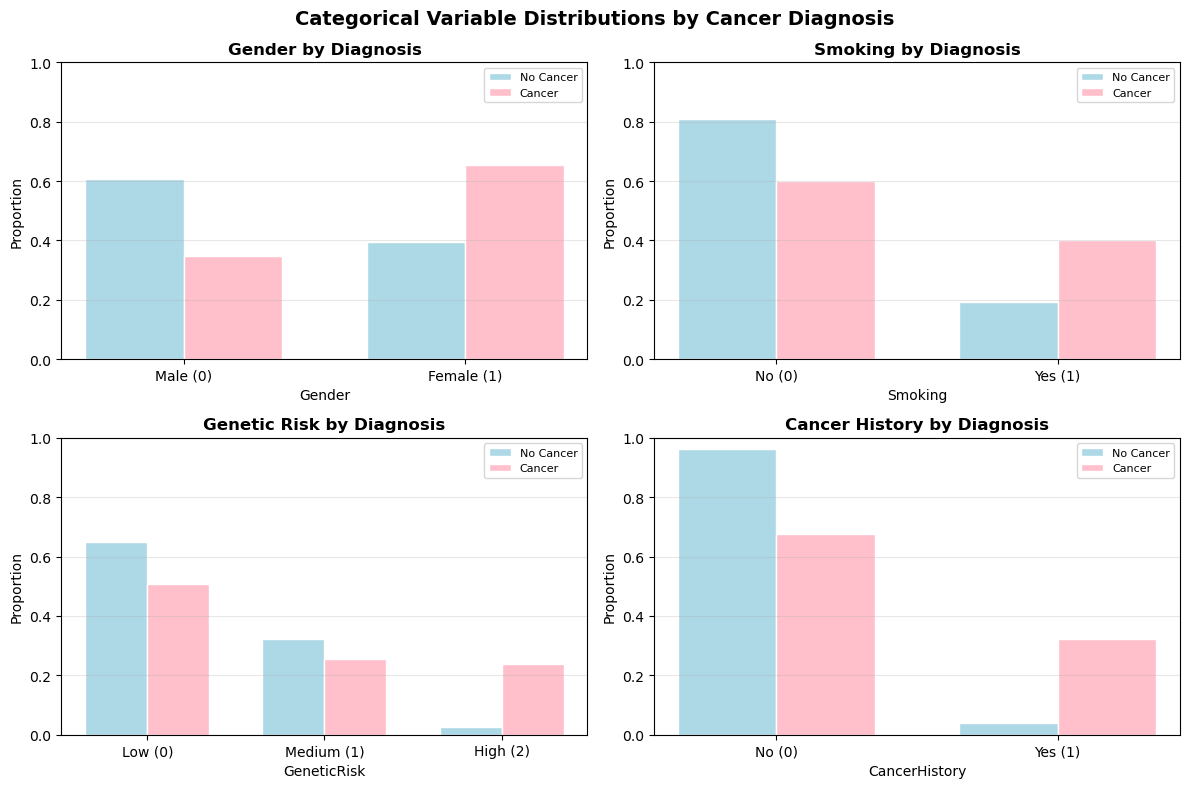

In [ ]:
no_cancer = df[df['Diagnosis'] == 0]
with_cancer = df[df['Diagnosis'] == 1]

def plot_categorical_by_diagnosis(ax, df, col, labels, title):
    no_cancer_plt = no_cancer[col].value_counts(normalize=True).sort_index()
    with_cancer_plt = with_cancer[col].value_counts(normalize=True).sort_index()

    categories = sorted(df[col].dropna().unique())
    no_cancer_plt = no_cancer_plt.reindex(categories, fill_value=0)
    with_cancer_plt = with_cancer_plt.reindex(categories, fill_value=0)
    
    x = np.arange(len(categories))
    width = 0.35
    
    ax.bar(x - width/2, no_cancer_plt.values, width, label='No Cancer', color='lightblue', edgecolor='white')
    ax.bar(x + width/2, with_cancer_plt.values, width, label='Cancer', color='pink', edgecolor='white')
    
    ax.set_title(title, fontsize=12, fontweight='bold')
    ax.set_xlabel(col, fontsize=10)
    ax.set_ylabel('Proportion', fontsize=10)
    ax.set_xticks(x)
    ax.set_xticklabels(labels)
    ax.set_ylim(0, 1)
    ax.legend(fontsize=8)
    ax.grid(True, alpha=0.3, axis='y')


fig, axes = plt.subplots(2, 2, figsize=(12, 8))
axes = axes.ravel()

plot_categorical_by_diagnosis(axes[0], cancer, 'Gender', ['Male (0)', 'Female (1)'], 'Gender by Diagnosis')
plot_categorical_by_diagnosis(axes[1], cancer, 'Smoking', ['No (0)', 'Yes (1)'], 'Smoking by Diagnosis')
plot_categorical_by_diagnosis(axes[2], cancer, 'GeneticRisk', ['Low (0)', 'Medium (1)', 'High (2)'], 'Genetic Risk by Diagnosis')
plot_categorical_by_diagnosis(axes[3], cancer, 'CancerHistory', ['No (0)', 'Yes (1)'], 'Cancer History by Diagnosis')

plt.suptitle('Categorical Variable Distributions by Cancer Diagnosis', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

In [68]:
summary_table = pd.DataFrame({

    'Factor': [
        'Age',
        'BMI',
        'Smoking (%)',
        'Female (%)',
        'High Genetic Risk (%)',
        'Physical Activity',
        'Alcohol Intake',
        'Cancer History (%)'
    ],

    'No Cancer': [
        round(no_cancer['Age'].mean(), 2),
        round(no_cancer['BMI'].mean(), 2),
        round((no_cancer['Smoking'] == 1).mean() * 100, 2),
        round((no_cancer['Gender'] == 1).mean() * 100, 2),
        round((no_cancer['GeneticRisk'] == 2).mean() * 100, 2),
        round(no_cancer['PhysicalActivity'].mean(), 2),
        round(no_cancer['AlcoholIntake'].mean(), 2),
        round((no_cancer['CancerHistory'] == 1).mean() * 100, 2)
    ],

    'With Cancer': [
        round(with_cancer['Age'].mean(), 2),
        round(with_cancer['BMI'].mean(), 2),
        round((with_cancer['Smoking'] == 1).mean() * 100, 2),
        round((with_cancer['Gender'] == 1).mean() * 100, 2),
        round((with_cancer['GeneticRisk'] == 2).mean() * 100, 2),
        round(with_cancer['PhysicalActivity'].mean(), 2),
        round(with_cancer['AlcoholIntake'].mean(), 2),
        round((with_cancer['CancerHistory'] == 1).mean() * 100, 2)
    ]

}).set_index('Factor')

summary_table

,No Cancer,With Cancer
Factor,,
Age,47.66,54.83
BMI,26.47,29.28
Smoking (%),19.19,40.04
Female (%),39.45,65.35
High Genetic Risk (%),2.65,23.88
Physical Activity,5.23,4.34
Alcohol Intake,2.19,2.81
Cancer History (%),3.82,32.32



Individuals WITHOUT Cancer vs WITH Cancer:

* Individuals with cancer are older on average (54.83 vs 47.66 years).
* Individuals with cancer have a higher average BMI (29.28 vs 26.47).
* The proportion of smokers is substantially higher among individuals with cancer (40.04% vs 19.19%).
* Females make up a larger proportion of the cancer group (65.35% vs 39.45%).
* High genetic risk is much more common in the cancer group (23.88% vs 2.65%).
* Cancer patients tend to have lower physical activity levels (4.34 vs 5.23).
* Individuals with cancer consume more alcohol on average (2.81 vs 2.19).
* Individuals with a prior cancer history are significantly more represented in the cancer group (32.32% vs 3.82%).

### 4. Statistical Analysis
##### Chi-squared 
To analysis categorical variables.

In [62]:
from scipy.stats import chi2_contingency, ttest_ind

# 1) Chi-squared (categoricals)
chi2s = []
for col in categorical_cols:
    contingency = pd.crosstab(cancer[col], cancer["Diagnosis"])
    chi2, p_value, dof, expected = chi2_contingency(contingency)

    n = contingency.values.sum()
    r, k = contingency.shape

    cramer_v = np.sqrt(chi2 / (n * max(min(r - 1, k - 1), 1)))
    if cramer_v <= 0.1:
        cramer_v_stength = 'Weak'
    elif cramer_v <= 0.3:
        cramer_v_stength = 'Medium'
    else:
        cramer_v_stength = 'Strong'

    chi2s.append({
        "Chi-squared": chi2,
        "p-value": p_value,
        "Significant (p<0.05)": p_value < 0.05,
        "Cramér's V": cramer_v,
        "Cramér's V Strength": cramer_v_stength,
        })

chi2_df = pd.DataFrame(chi2s, index=categorical_cols).sort_values("p-value")
print("Chi-squared tests: Categorical feature vs Diagnosis")
display(chi2_df)

Chi-squared tests: Categorical feature vs Diagnosis


,Chi-squared,p-value,Significant (p<0.05),Cramér's V,Cramér's V Strength
CancerHistory,228.410798,1.324116e-51,True,0.390223,Strong
GeneticRisk,167.432582,4.390124e-37,True,0.334098,Strong
Gender,92.968527,5.313258e-22,True,0.248956,Medium
Smoking,76.237267,2.515495e-18,True,0.225444,Medium


CancerHistory and GeneticRisk are highly significant and have strong association with diagnosis (higher χ² and strong V).

Gender and Smoking are highly significant, but weaker association strength than the top two (Medium V).


#### T-tests 
To analysis continuous variables.

In [61]:
tests = []

for col in continous_cols:
    group_no = cancer.loc[cancer["Diagnosis"] == 0, col].dropna()
    group_yes = cancer.loc[cancer["Diagnosis"] == 1, col].dropna()

    t_stat, p_value = ttest_ind(group_no, group_yes, equal_var=False)

    n1, n2 = len(group_no), len(group_yes)
    s1, s2 = group_no.std(ddof=1), group_yes.std(ddof=1)
    pooled_sd = np.sqrt(((n1 - 1) * s1**2 + (n2 - 1) * s2**2) / (n1 + n2 - 2))
    
    cohen_d = np.abs((group_yes.mean() - group_no.mean()) / pooled_sd) if pooled_sd > 0 else np.nan
    if cohen_d < 0.2:
        cohen_d_strength = 'Small'
    elif cohen_d < 0.5:
        cohen_d_strength = 'Medium'
    else:
        cohen_d_strength = 'Large' 

    tests.append({
        "t-stat": t_stat,
        "p-value": p_value,
        "Significant (p<0.05)": p_value < 0.05,
        "|Cohen’s d|": cohen_d,
        "Cohen’s d strength": cohen_d_strength,
        })

ttest_df = pd.DataFrame(tests, index=continous_cols).sort_values("p-value")
print("\nt-tests: Continuous feature means by Diagnosis")
display(ttest_df)


t-tests: Continuous feature means by Diagnosis


,t-stat,p-value,Significant (p<0.05),|Cohen’s d|,Cohen’s d strength
AlcoholIntake,-8.362728,1.771755e-16,True,0.450394,Medium
Age,-7.846796,9.350830e-15,True,0.414732,Medium
BMI,-7.584778,6.435918e-14,True,0.394943,Medium
PhysicalActivity,5.761972,1.079336e-08,True,0.313988,Medium


AlcoholIntake, Age, BMI, PhysicalActivity are highly significant and have medium association with diagnosis.

### 5. Logistic Regression Model
#### Baseline Logistic Regression

In [101]:
cols = cancer.columns.drop('Diagnosis')

X = cancer[cols]
y = cancer['Diagnosis']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

baseline_model = Pipeline([
    ('scaler', StandardScaler()),
    ('logreg', LogisticRegression(max_iter=1000))
])

baseline_model.fit(X_train, y_train)
baseline_predictions = baseline_model.predict(X_test)
baseline_probabilities = baseline_model.predict_proba(X_test)[:, 1]

# Train accuracy
train_predictions = baseline_model.predict(X_train)
train_accuracy = accuracy_score(y_train, train_predictions)

# Test accuracy
test_accuracy = accuracy_score(y_test, baseline_predictions)
print("Train Accuracy:", round(train_accuracy, 4))
print("Test Accuracy:", round(test_accuracy, 4))

print("Baseline Logistic Regression Results")
print("Accuracy:", round(accuracy_score(y_test, baseline_predictions), 4))
print("Precision:", round(precision_score(y_test, baseline_predictions), 4))
print("Recall:", round(recall_score(y_test, baseline_predictions), 4))
print("F1 Score:", round(f1_score(y_test, baseline_predictions), 4))
print("ROC-AUC:", round(roc_auc_score(y_test, baseline_probabilities), 4))

df_base = pd.DataFrame(classification_report(y_test, baseline_predictions, output_dict=True)).transpose()
df_base = df_base.rename(index={'0': 'Non-Cancer','1': 'Cancer'})
df_base.columns.name = 'Classification Report'
df_base

Train Accuracy: 0.855
Test Accuracy: 0.8433
Baseline Logistic Regression Results
Accuracy: 0.8433
Precision: 0.7963
Recall: 0.7748
F1 Score: 0.7854
ROC-AUC: 0.9167


Classification Report,precision,recall,f1-score,support
Non-Cancer,0.869792,0.883598,0.876640,189.000000
Cancer,0.796296,0.774775,0.785388,111.000000
accuracy,0.843333,0.843333,0.843333,0.843333
macro avg,0.833044,0.829186,0.831014,300.000000
weighted avg,0.842598,0.843333,0.842877,300.000000


The baseline logistic regression model demonstrated strong predictive performance in classifying cancer diagnoses. The model achieved an overall accuracy of 84.33%, indicating that it correctly classified the majority of patients in the test dataset.

The model produced a precision score of 79.63%, meaning that when the model predicted a positive cancer diagnosis, approximately 80% of those predictions were correct. The recall score of 77.48% indicates that the model successfully identified about 77% of actual cancer cases.

The resulting F1 score of 78.54% suggests a balanced tradeoff between precision and recall, demonstrating stable classification performance across both cancer and non-cancer groups.

Additionally, the model achieved a high ROC-AUC score of 0.9167, indicating excellent discriminatory ability between patients with and without cancer. An ROC-AUC value above 0.9 generally reflects a strong classification model.

From the classification report:
* The model performed slightly better in identifying non-cancer cases, achieving precision and recall values above 86%.
* Performance for cancer cases remained strong, with precision near 80% and recall around 77%.
* The weighted average F1 score of approximately 84% indicates consistent overall predictive performance across the dataset.

The logistic regression model does not exhibit significant overfitting. The training accuracy (85.50%) and testing accuracy (84.33%) are very close. This indicates that the model generalizes well to unseen data and maintains stable predictive performance across both training and testing datasets.

### 6. Model Evaluation

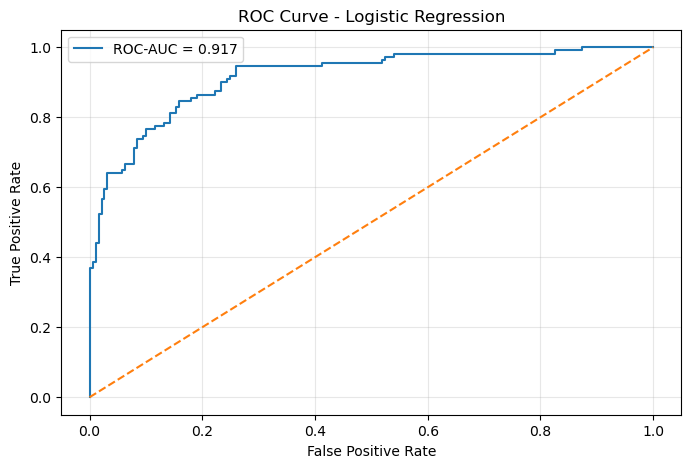

In [104]:
y_prob = baseline_model.predict_proba(X_test)[:, 1]
fpr, tpr, thresholds = roc_curve(y_test, y_prob)

plt.figure(figsize=(8,5))
plt.plot(fpr, tpr, label=f'ROC-AUC = {roc_auc_score(y_test, y_prob):.3f}')
plt.plot([0,1], [0,1], linestyle='--')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve - Logistic Regression')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

The ROC curve demonstrates the classification performance of the logistic regression model across different probability thresholds. The curve is positioned close to the upper-left corner, indicating strong discriminative ability between cancer and non-cancer patients.

The ROC-AUC score of this model is 0.917, which has excellent overall classification performance (ROC-AUC score = 1.0: perfect classification). Therefore, this model can effectively distinguish between positive and negative cancer diagnoses.

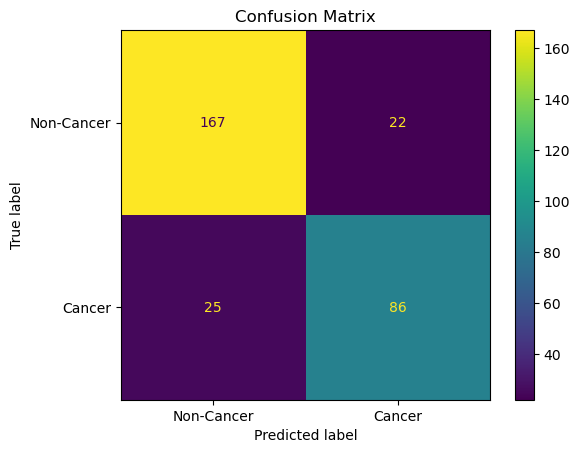

In [105]:
cm = confusion_matrix(y_test, baseline_predictions)
disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=['Non-Cancer', 'Cancer']
)

disp.plot()
plt.title('Confusion Matrix')
plt.show()

The confusion matrix shows that the logistic regression model correctly classified most patients in the dataset. The model correctly identified 167 non-cancer patients and 86 cancer patients.

However, 22 non-cancer patients were incorrectly predicted as cancer (false positives), while 25 cancer patients were incorrectly classified as non-cancer (false negatives).

### 7. Feature Importance Analysis
#### Coefficient

In [118]:
coef_table = pd.DataFrame({
    'Feature': cancer.columns.drop('Diagnosis'),
    'Coefficient': baseline_model.named_steps['logreg'].coef_[0]
})

coef_table['Absolute Coefficient'] = coef_table['Coefficient'].abs()
coef_table.sort_values(by='Absolute Coefficient', ascending=False).set_index('Feature')

,Coefficient,Absolute Coefficient
Feature,,
CancerHistory,1.446720,1.446720
Gender,1.034865,1.034865
GeneticRisk,1.007050,1.007050
AlcoholIntake,0.927989,0.927989
Age,0.887922,0.887922
Smoking,0.881395,0.881395
BMI,0.817267,0.817267
PhysicalActivity,-0.680357,0.680357


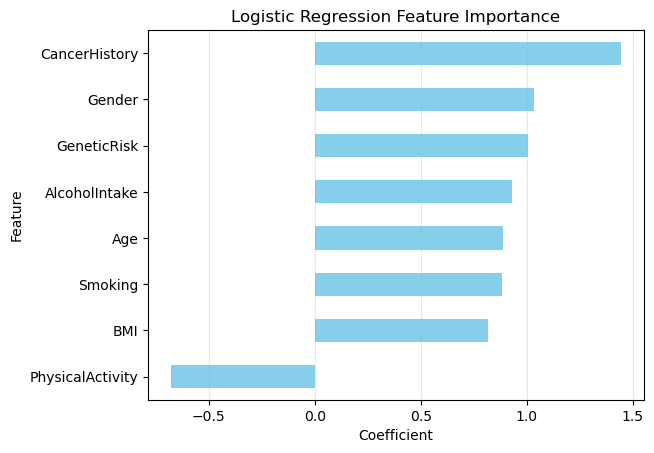

In [119]:
coef_table.sort_values(by='Coefficient').plot(x='Feature', y='Coefficient', kind='barh', color='skyblue', legend=False)
plt.grid(True, alpha=0.3, axis='x')
plt.title('Logistic Regression Feature Importance')
plt.xlabel('Coefficient')
plt.show()

The coefficient for CancerHistory is the largest (1.447), indicating that cancer history is the most important cancer predictor in this dataset.

A positive coefficient indicates that as these variables increase, the model's probability of predicting cancer also increases.

Conversely, the coefficient for PhysicalActivity is negative (-0.680), indicating that higher levels of physical activity can reduce the risk of cancer.

### 8. Conclusion
This project explored the relationship between lifestyle and genetic factors and cancer diagnosis using statistical analysis and machine learning techniques. Exploratory data analysis revealed clear differences between individuals with and without cancer across several important health-related variables.
##### Key Findings
* Cancer patients were generally older and had higher BMI values.
* Smoking, genetic risk, and cancer history showed strong associations with cancer diagnosis.
* Physical activity demonstrated a negative relationship with predicted cancer risk.
* Logistic regression achieved strong predictive performance with ROC-AUC above 0.91.
* The model generalized well without significant overfitting.

Statistical analysis showed that individuals diagnosed with cancer were generally older, had higher BMI values, consumed more alcohol, and participated in lower levels of physical activity. In addition, smoking, high genetic risk, and prior cancer history were substantially more common among individuals with cancer.

To further evaluate predictive relationships between these variables and cancer diagnosis, a multivariate logistic regression model was implemented. The model achieved strong predictive performance, with an accuracy of approximately 84% and an ROC-AUC score of 0.917, indicating excellent classification capability. Comparison between training and testing accuracy also suggested that the model generalized well and did not exhibit significant overfitting.

Feature coefficient analysis identified cancer history, gender, genetic risk, alcohol intake, age, smoking, and BMI as strong positive contributors to cancer prediction, while physical activity demonstrated a negative relationship with cancer risk.

Overall, the results suggest that both lifestyle-related and genetic factors play important roles in cancer diagnosis prediction. The logistic regression model demonstrated that relatively interpretable machine learning methods can effectively classify cancer risk using patients' lifestyles and health-related information.

### 9. Limitations
- This dataset may not represent the full real-world patient population.

- Correlation does not imply causation.

- Logistic regression assumes linear relationships between predictors and log-odds.

- Additional clinical variables may improve predictive performance.


### 10. Ethical Considerations
#### Data Collection
The datasets were collected and published publicly on Kaggle which follows ethical policies and already asked contributors to adhere to data sharing. This dataset was collected by the original data providers, they have already obtained informed consent. Since the dataset was not collected by us, we will not directly interact with human subjects.

The dataset was surveyed from 1500 patients for their lifestyle habits and their physical health features. The patients are adults ranging in the ages of 20 to 80. This dataset includes age and gender to compare if these factors have a relationship to cancer. 
The Kaggle dataset is anonymized and does not include personally identifiable information (PII). No identifying data (e.g., names, emails, addresses) are collected or used.  

#### Data Storage
The dataset is publicly available from Kaggle, and is synthetic. Local or processed versions of the data will only be shared within our team and for the purpose of the project. Any processed files won’t be shared to the public, however, since the dataset is publicly available and synthetic, there are no concerns about accidentally sharing any PII to the public, even if this was the case. 

#### Data Analysis 
When analyzing different populations within the dataset, it is important that we do not draw simple conclusions without considering any causal mechanisms or relationships. It is also important that we consider whether trends among populations are accurately represented: as an example, gender is a significant feature considered in the data. We will also make sure to account for data biases of class imbalances and skews within the data (e.g. smokers/non-smokers, diagnosed/not-diagnosed) by accurately representing that bias in our data. Anatomical differences may display trends that are not present in the overall population and will be made clear in the analysis. The dataset being public from Kaggle means that privacy is accounted for by not giving any information about patients outside of what was given to us. Analysis will be fully documented on a program that’s able to record edit histories so that transparency is given to what parts of the data influence our representation.

#### Modeling (Statistical or Machine Learning)
When creating any statistical or predictive models, it is crucial that we are aware of any skewed distributions or biased data from within the dataset, especially when considering features like genetic risk. When examining subsets such as populations past retirement age, we need to be aware of external factors such as advances in technology and healthcare, and changes in smoking and drinking culture that may affect the specified subset. We will also use techniques like cross-validation to ensure consistent performance across both the training and testing sets. 

#### Project or Model Deployment
Since the model was trained by a medium size dataset and is technically synthetic, it doesn’t cover everyone’s information and doesn’t take every risk factor into account. The model’s results will need to be closely tracked as it can potentially lead to misconception in the understanding of the influence of different habits on cancer. Although it is highly unlikely that this model will be used for malpractice or fraud in the medical industry, it might cause some unintended harm. Therefore, it’s essential to create safeguards that ethically consider systemic biases, and ensure results are considered with a nuanced take.

### Group Contributions
* Adit Gautam : Wrote the following sections: Analysis Methods 1&2, Interpreting Results, Data Collection. Revised other sections for flow and consistency.
* Skyler Kim : Societal/ethical implications, data analysis revisions.
* Hsin Yu Ho: Data collection, Descriptive & Exploratory Data Analysis and edit Data Visualization, Coding, Limitation, and Conclusion parts. 
* Somprat Suratannon : Data Wrangling, Data Visualization, How will address these issues.
* Noah Teng : Limitations compounds and Biases, revised: Ethical Considerations Data Analysis.